# Alzheimer's Disease Diagnosis — ML pipeline END TO END

**Dataset:** ADNI-style clinical, cognitive, and neuroimaging features  
**Target:** Multi-class diagnosis — `CN` (Cognitively Normal), `SMC`, `EMCI`, `LMCI`, `AD`  
**Samples:** 1,737 subjects · 371 features

---
### checklist:
1. Data Loading & Audit  
2. Exploratory Data Analysis (EDA)  
3. Preprocessing (cleaning, encoding, scaling)  
4. Feature Engineering & Selection  
5. Model Training — multiple classifiers with cross-validation  
6. Hyperparameter Tuning  
7. Evaluation & Comparison  
8. Feature Importance & Explainability  
9. Confusion Matrix & Clinical Insights  

In [1]:
# (kaggle-only cell, skipped locally)


In [2]:
# ─── 1. IMPORTS ───────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# Metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, f1_score
)

# Display config.
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
print("All imports are successful.")

All imports are successful.


---
## 1 · Data Loading & Initial Audit

In [3]:
# ─── 2. LOAD DATA ─────────────────────────────────────────────────────────────
df = pd.read_csv('Alzheimer_DataSet.csv')

print(f"Dataset shape : {df.shape}")
print(f"Rows          : {df.shape[0]:,}")
print(f"Columns       : {df.shape[1]}")
df.head(3)

Dataset shape : (1737, 371)
Rows          : 1,737
Columns       : 371


,RID,Test_data,Diagnosis,FDG_PET,CDRSB,ADAS11,ADAS13,MMSE,RAVLT_immediate,RAVLT_learning,RAVLT_forgetting,RAVLT_perc_forgetting,Age,Gender,Year_education,...,Cortical Thickness Standard Deviation of RightLateralOrbitofrontal,Volume (WM Parcellation) of RightLateralVentricle,Volume (Cortical Parcellation) of RightLingual,Surface Area of RightLingual,Cortical Thickness Average of RightLingual,Cortical Thickness Standard Deviation of RightLingual,Volume (Cortical Parcellation) of RightMedialOrbitofrontal,Surface Area of RightMedialOrbitofrontal,Cortical Thickness Average of RightMedialOrbitofrontal,Cortical Thickness Standard Deviation of RightMedialOrbitofrontal,Volume (Cortical Parcellation) of RightMiddleTemporal,Surface Area of RightMiddleTemporal,Cortical Thickness Average of RightMiddleTemporal,Cortical Thickness Standard Deviation of RightMiddleTemporal,Volume (WM Parcellation) of FourthVentricle
0,2,0,CN,1.3693,0.0000,10.6700,18.6700,28,44.0000,4.0000,6.0000,54.5455,74.3000,Male,16,...,0.8420,55425.0000,8142.0000,3516.0000,2.0790,0.6940,3835.0000,1622.0000,2.0770,0.7460,15683.0000,4272.0000,3.0280,0.6490,4396.0000
1,3,0,AD,1.0908,4.5000,22.0000,31.0000,20,22.0000,1.0000,4.0000,100.0000,81.3000,Male,18,...,0.7670,28743.0000,6254.0000,3130.0000,1.7650,0.5910,3681.0000,1734.0000,1.9420,0.6960,10387.0000,3316.0000,2.5450,0.6860,3304.0000
2,4,1,LMCI,1.2455,1.0000,14.3300,21.3300,27,37.0000,7.0000,4.0000,36.3636,67.5000,Male,10,...,0.7370,18952.0000,7625.0000,3696.0000,1.9290,0.5880,4060.0000,1728.0000,2.1800,0.6070,11156.0000,3598.0000,2.6700,0.6310,1338.0000


In [4]:
# ─── 3. DATA AUDIT ────────────────────────────────────────────────────────────
print("=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)
print(df['Diagnosis'].value_counts())
print()

print("=" * 60)
print("DATA TYPES")
print("=" * 60)
cat_cols  = df.select_dtypes(include='object').columns.tolist()
num_cols  = df.select_dtypes(include='number').columns.tolist()
print(f"  Numeric columns  : {len(num_cols)}")
print(f"  Categorical cols : {len(cat_cols)} → {cat_cols}")
print()

print("=" * 60)
print("MISSING VALUES")
print("=" * 60)
null_counts   = df.isnull().sum()
fully_null    = null_counts[null_counts == len(df)]
partial_null  = null_counts[(null_counts > 0) & (null_counts < len(df))]
print(f"  Fully-null columns  : {len(fully_null)}  (will be dropped)")
print(f"  Partially-null cols : {len(partial_null)}")
print()
print("=" * 60)
print("DUPLICATES")
print("=" * 60)
print(f"  Duplicate rows      : {df.duplicated().sum()}")

TARGET DISTRIBUTION
Diagnosis
LMCI    562
CN      417
AD      342
EMCI    310
SMC     106
Name: count, dtype: int64

DATA TYPES
  Numeric columns  : 366
  Categorical cols : 5 → ['Diagnosis', 'Gender', 'Ethnicity', 'Race', 'Marital_status']

MISSING VALUES
  Fully-null columns  : 17  (will be dropped)
  Partially-null cols : 0

DUPLICATES


  Duplicate rows      : 0


C:\Users\bbc01\AppData\Local\Temp\ipykernel_11136\80153087.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols  = df.select_dtypes(include='object').columns.tolist()


---
## 2 · Exploratory Data Analysis

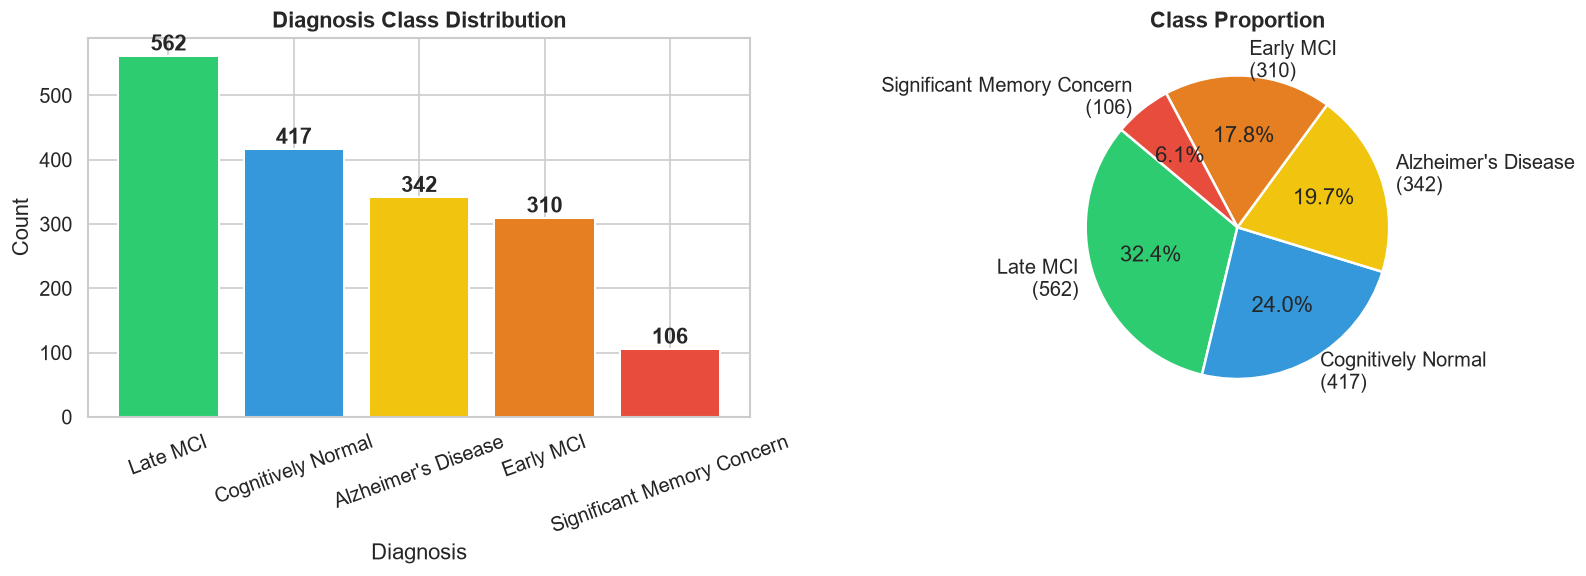

In [5]:
# ─── 4. TARGET DISTRIBUTION ───────────────────────────────────────────────────
label_map = {
    'CN'  : 'Cognitively Normal',
    'SMC' : 'Significant Memory Concern',
    'EMCI': 'Early MCI',
    'LMCI': 'Late MCI',
    'AD'  : "Alzheimer's Disease"
}

diag_counts = df['Diagnosis'].value_counts()
diag_labels = [label_map.get(d, d) for d in diag_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# For Bar chart
colors = ['#2ECC71','#3498DB','#F1C40F','#E67E22','#E74C3C']
axes[0].bar(diag_labels, diag_counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Diagnosis Class Distribution', fontweight='bold')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(diag_counts.values):
    axes[0].text(i, v + 8, str(v), ha='center', fontweight='bold')

# For Pie chart
axes[1].pie(
    diag_counts.values,
    labels=[f"{l}\n({v})" for l, v in zip(diag_labels, diag_counts.values)],
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Class Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight')
plt.show()

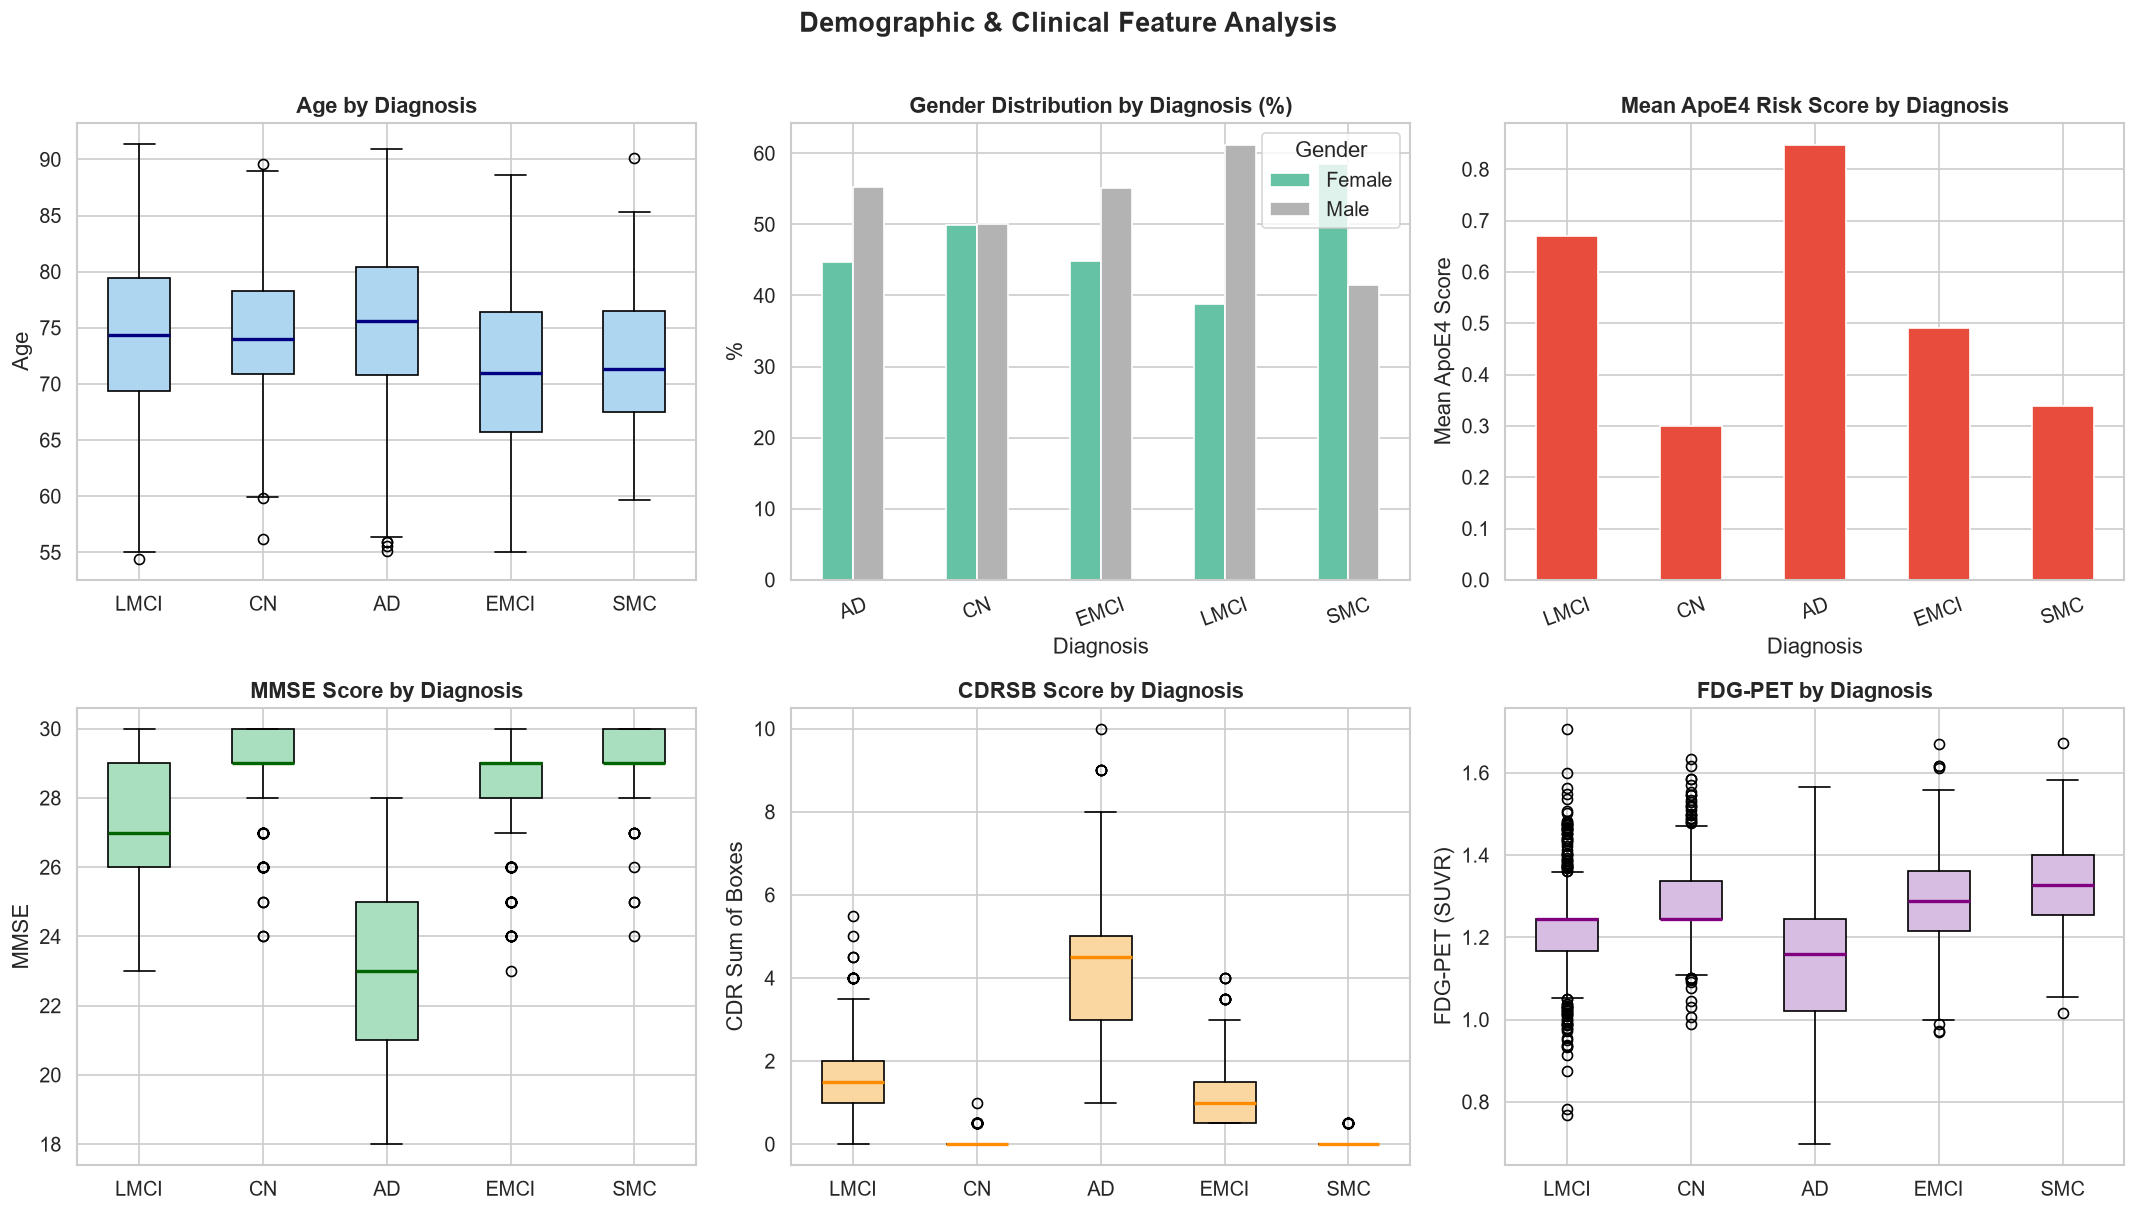

In [6]:
# ─── 5. DEMOGRAPHIC ANALYSIS ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Age distribution by diagnosis
groups = [df[df['Diagnosis'] == d]['Age'].dropna() for d in diag_counts.index]
axes[0,0].boxplot(groups, tick_labels=list(diag_counts.index), patch_artist=True,
                  boxprops=dict(facecolor='#AED6F1'), medianprops=dict(color='navy', linewidth=2))
axes[0,0].set_title('Age by Diagnosis', fontweight='bold')
axes[0,0].set_ylabel('Age')

# Gender breakdown
gender_diag = pd.crosstab(df['Diagnosis'], df['Gender'], normalize='index') * 100
gender_diag.plot(kind='bar', ax=axes[0,1], colormap='Set2', edgecolor='white')
axes[0,1].set_title('Gender Distribution by Diagnosis (%)', fontweight='bold')
axes[0,1].set_xlabel('Diagnosis')
axes[0,1].set_ylabel('%')
axes[0,1].tick_params(axis='x', rotation=20)
axes[0,1].legend(title='Gender', loc='upper right')

# ApoE4 risk
apoe_diag = df.groupby('Diagnosis')['High_risk_ApoE4'].mean().reindex(diag_counts.index)
apoe_diag.plot(kind='bar', ax=axes[0,2], color='#E74C3C', edgecolor='white')
axes[0,2].set_title('Mean ApoE4 Risk Score by Diagnosis', fontweight='bold')
axes[0,2].set_ylabel('Mean ApoE4 Score')
axes[0,2].tick_params(axis='x', rotation=20)

# MMSE scores
groups_mmse = [df[df['Diagnosis'] == d]['MMSE'].dropna() for d in diag_counts.index]
axes[1,0].boxplot(groups_mmse, tick_labels=list(diag_counts.index), patch_artist=True,
                  boxprops=dict(facecolor='#A9DFBF'), medianprops=dict(color='darkgreen', linewidth=2))
axes[1,0].set_title('MMSE Score by Diagnosis', fontweight='bold')
axes[1,0].set_ylabel('MMSE')

# CDRSB scores
groups_cdr = [df[df['Diagnosis'] == d]['CDRSB'].dropna() for d in diag_counts.index]
axes[1,1].boxplot(groups_cdr, tick_labels=list(diag_counts.index), patch_artist=True,
                  boxprops=dict(facecolor='#FAD7A0'), medianprops=dict(color='darkorange', linewidth=2))
axes[1,1].set_title('CDRSB Score by Diagnosis', fontweight='bold')
axes[1,1].set_ylabel('CDR Sum of Boxes')

# FDG PET
groups_fdg = [df[df['Diagnosis'] == d]['FDG_PET'].dropna() for d in diag_counts.index]
axes[1,2].boxplot(groups_fdg, tick_labels=list(diag_counts.index), patch_artist=True,
                  boxprops=dict(facecolor='#D7BDE2'), medianprops=dict(color='purple', linewidth=2))
axes[1,2].set_title('FDG-PET by Diagnosis', fontweight='bold')
axes[1,2].set_ylabel('FDG-PET (SUVR)')

plt.suptitle('Demographic & Clinical Feature Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_demographics.png', bbox_inches='tight')
plt.show()

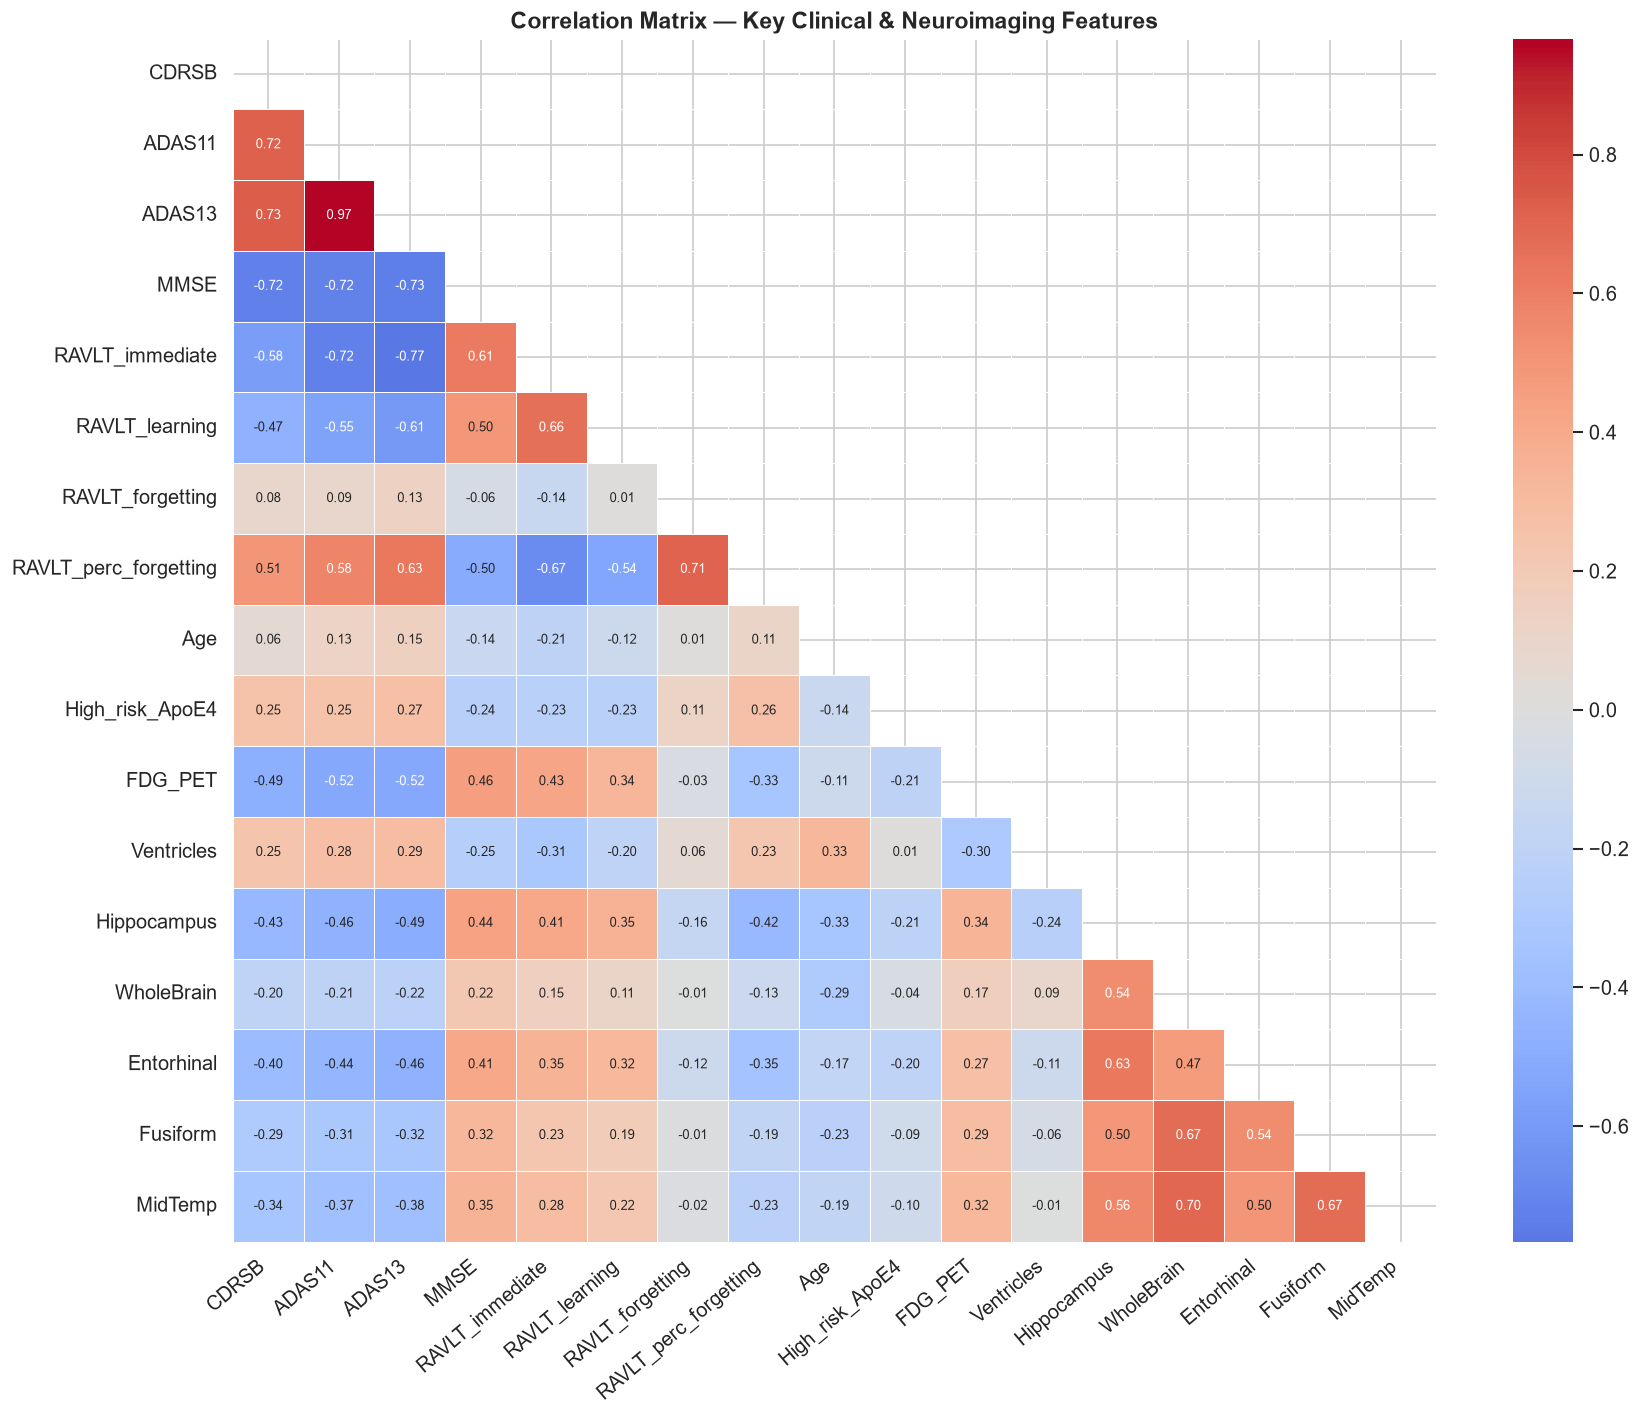

In [7]:
# ─── 6. CORRELATION HEATMAP (KEY CLINICAL FEATURES) ──────────────────────────
clinical_features = [
    'CDRSB','ADAS11','ADAS13','MMSE',
    'RAVLT_immediate','RAVLT_learning','RAVLT_forgetting','RAVLT_perc_forgetting',
    'Age','High_risk_ApoE4','FDG_PET',
    'Ventricles','Hippocampus','WholeBrain','Entorhinal','Fusiform','MidTemp'
]

corr_matrix = df[clinical_features].corr()

plt.figure(figsize=(15, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}, square=True
)
plt.title('Correlation Matrix — Key Clinical & Neuroimaging Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=40, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

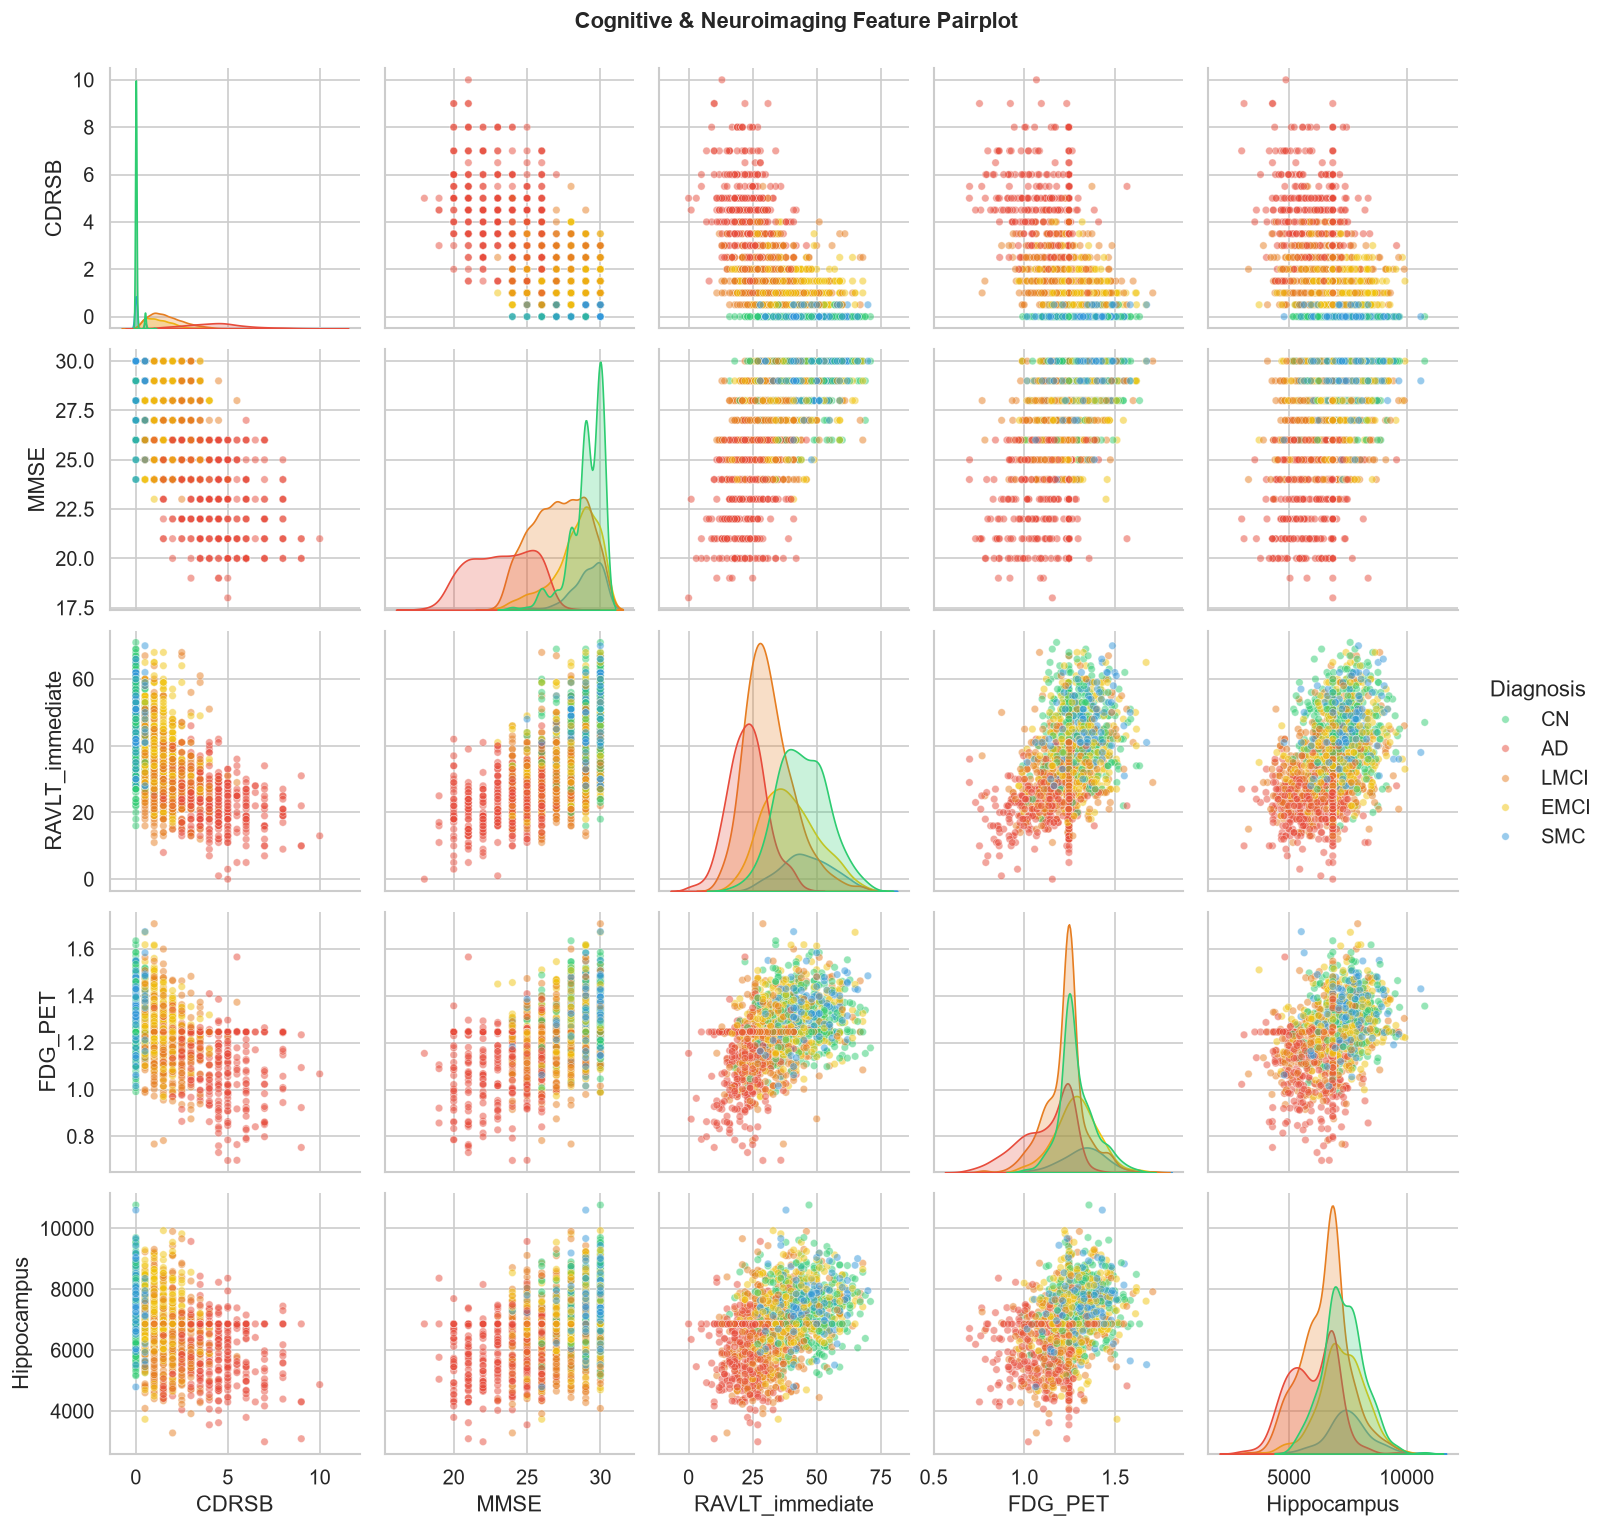

In [8]:
# ─── 7. COGNITIVE SCORES PAIRPLOT ─────────────────────────────────────────────
cog_features = ['CDRSB','MMSE','RAVLT_immediate','FDG_PET','Hippocampus','Diagnosis']
pair_df = df[cog_features].dropna()

palette = {'CN': '#2ECC71', 'SMC': '#3498DB', 'EMCI': '#F1C40F',
           'LMCI': '#E67E22', 'AD': '#E74C3C'}

g = sns.pairplot(
    pair_df, hue='Diagnosis', palette=palette,
    diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20},
    vars=['CDRSB','MMSE','RAVLT_immediate','FDG_PET','Hippocampus']
)
g.fig.suptitle('Cognitive & Neuroimaging Feature Pairplot', y=1.02, fontsize=13, fontweight='bold')
plt.savefig('pairplot.png', bbox_inches='tight')
plt.show()

---
## 3 · Preprocessing

In [9]:
# ─── 8. PREPROCESSING ─────────────────────────────────────────────────────────

# 8a. Drop fully-null columns
fully_null_cols = df.columns[df.isnull().sum() == len(df)].tolist()
df_clean = df.drop(columns=fully_null_cols)
print(f"Dropped {len(fully_null_cols)} fully-null columns. Remaining: {df_clean.shape[1]}")

# 8b. Drop identifier / leakage columns
drop_cols = ['RID', 'Test_data']
df_clean = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns])
print(f"Dropped identifier columns. Remaining: {df_clean.shape[1]}")

# 8c. Encode categorical columns (excluding target)
cat_features = [c for c in df_clean.select_dtypes(include='object').columns if c != 'Diagnosis']
print(f"\nEncoding categorical features: {cat_features}")

le_dict = {}
for col in cat_features:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    le_dict[col] = le
    print(f"  {col}: {le.classes_.tolist()}")

# 8d. Encode target
DIAGNOSIS_ORDER = ['CN', 'SMC', 'EMCI', 'LMCI', 'AD']  # ordered by severity
le_target = LabelEncoder()
le_target.fit(DIAGNOSIS_ORDER)
df_clean['Diagnosis_encoded'] = le_target.transform(df_clean['Diagnosis'])
print(f"\nTarget encoding: {dict(zip(DIAGNOSIS_ORDER, le_target.transform(DIAGNOSIS_ORDER)))}")

print(f"\n✅ Preprocessing complete. Shape: {df_clean.shape}")

Dropped 17 fully-null columns. Remaining: 354
Dropped identifier columns. Remaining: 352

Encoding categorical features: ['Gender', 'Ethnicity', 'Race', 'Marital_status']
  Gender: ['Female', 'Male']
  Ethnicity: ['Hisp/Latino', 'Not Hisp/Latino']
  Race: ['Am Indian/Alaskan', 'Asian', 'Black', 'Hawaiian/Other PI', 'More than one', 'White']
  Marital_status: ['Divorced', 'Married', 'Never married', 'Unknown', 'Widowed']

Target encoding: {'CN': np.int64(1), 'SMC': np.int64(4), 'EMCI': np.int64(2), 'LMCI': np.int64(3), 'AD': np.int64(0)}

✅ Preprocessing complete. Shape: (1737, 353)


C:\Users\bbc01\AppData\Local\Temp\ipykernel_11136\3136602821.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = [c for c in df_clean.select_dtypes(include='object').columns if c != 'Diagnosis']
C:\Users\bbc01\AppData\Local\Temp\ipykernel_11136\3136602821.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean['Diagnosis_e

In [10]:
# ─── 9. FEATURE / TARGET SPLIT & IMPUTATION ───────────────────────────────────
X = df_clean.drop(columns=['Diagnosis', 'Diagnosis_encoded'])
y = df_clean['Diagnosis_encoded']

print(f"Feature matrix shape : {X.shape}")
print(f"Target vector shape  : {y.shape}")
print(f"Missing values in X  : {X.isnull().sum().sum()}")

# Median imputation for any remaining NaNs
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
print(f"Missing after imputation: {X_imputed.isnull().sum().sum()}")

Feature matrix shape : (1737, 351)
Target vector shape  : (1737,)
Missing values in X  : 0
Missing after imputation: 0


In [11]:
# ─── 10. TRAIN / TEST SPLIT ───────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Standardise
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)

print(f"Train set : {X_train_sc.shape}  |  classes: {dict(pd.Series(y_train).value_counts().sort_index())}")
print(f"Test set  : {X_test_sc.shape}   |  classes: {dict(pd.Series(y_test).value_counts().sort_index())}")

Train set : (1389, 351)  |  classes: {0: np.int64(274), 1: np.int64(333), 2: np.int64(248), 3: np.int64(449), 4: np.int64(85)}
Test set  : (348, 351)   |  classes: {0: np.int64(68), 1: np.int64(84), 2: np.int64(62), 3: np.int64(113), 4: np.int64(21)}


---
## 4 · Feature Selection

In [12]:
# ─── 11. FEATURE IMPORTANCE VIA RANDOM FOREST (PRE-SELECTION) ─────────────────
rf_selector = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_selector.fit(X_train_sc, y_train)

importance_df = pd.DataFrame({
    'Feature'  : X_train_sc.columns,
    'Importance': rf_selector.feature_importances_
}).sort_values('Importance', ascending=False)

TOP_N = 40
top_features = importance_df.head(TOP_N)['Feature'].tolist()

print(f"Top {TOP_N} features selected.")
print("\nTop 15 features:")
print(importance_df.head(15).to_string(index=False))

Top 40 features selected.

Top 15 features:
                                              Feature  Importance
                                                CDRSB      0.1063
                                               ADAS13      0.0329
                                                 MMSE      0.0302
                                               ADAS11      0.0283
                                      RAVLT_immediate      0.0195
                                RAVLT_perc_forgetting      0.0125
                                              FDG_PET      0.0090
                                       RAVLT_learning      0.0077
Cortical Thickness Standard Deviation of RightUnknown      0.0060
       Volume (Cortical Parcellation) of RightUnknown      0.0058
          Volume (WM Parcellation) of LeftHippocampus      0.0057
         Volume (WM Parcellation) of RightHippocampus      0.0057
        Cortical Thickness Average of RightEntorhinal      0.0056
                                

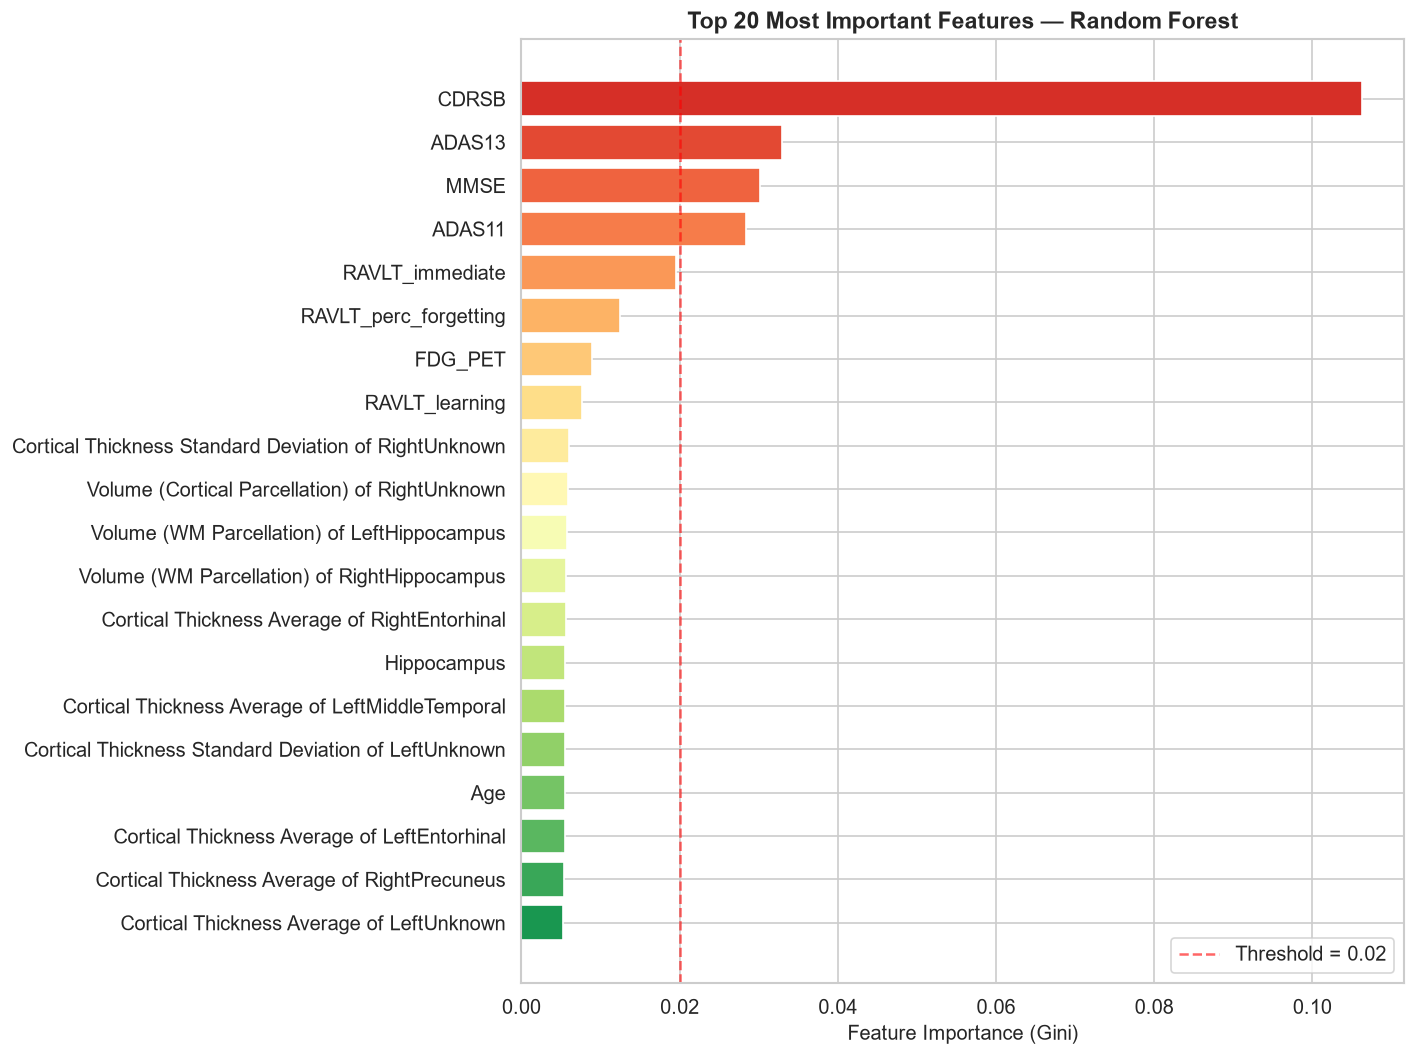

In [13]:
# ─── 12. FEATURE IMPORTANCE PLOT ──────────────────────────────────────────────
plt.figure(figsize=(12, 9))
top20 = importance_df.head(20)
colors_bar = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 20))
bars = plt.barh(top20['Feature'][::-1], top20['Importance'][::-1], color=colors_bar)
plt.xlabel('Feature Importance (Gini)', fontsize=12)
plt.title('Top 20 Most Important Features — Random Forest', fontsize=14, fontweight='bold')
plt.axvline(x=0.02, color='red', linestyle='--', alpha=0.6, label='Threshold = 0.02')
plt.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

In [14]:
# ─── 13. REDUCE TO TOP FEATURES ───────────────────────────────────────────────
X_train_top = X_train_sc[top_features]
X_test_top  = X_test_sc[top_features]
print(f"Reduced feature matrix: {X_train_top.shape}")

Reduced feature matrix: (1389, 40)


---
## 5 · Model Training & Cross-Validation

In [15]:
# ─── 14. MULTIPLE MODEL COMPARISON ────────────────────────────────────────────
models = {
    'Logistic Regression'       : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree'             : DecisionTreeClassifier(random_state=RANDOM_STATE),
    'K-Nearest Neighbours'      : KNeighborsClassifier(n_neighbors=7),
    'Support Vector Machine'    : SVC(probability=True, random_state=RANDOM_STATE),
    'Random Forest'             : RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'Extra Trees'               : ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting'         : GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_top, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    model.fit(X_train_top, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test_top))
    test_f1  = f1_score(y_test, model.predict(X_test_top), average='weighted')

    results.append({
        'Model'           : name,
        'CV Mean Acc'     : cv_scores.mean(),
        'CV Std'          : cv_scores.std(),
        'Test Accuracy'   : test_acc,
        'Test F1 (macro)' : test_f1
    })
    print(f"  {name:<28} | CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Test Acc: {test_acc:.4f} | F1: {test_f1:.4f}")

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)
print("\n" + "=" * 80)
print("MODEL RANKING")
print("=" * 80)
print(results_df.to_string(index=False))

  Logistic Regression          | CV: 0.7566 ± 0.0167 | Test Acc: 0.7270 | F1: 0.7166


  Decision Tree                | CV: 0.7091 ± 0.0176 | Test Acc: 0.7098 | F1: 0.7164


  K-Nearest Neighbours         | CV: 0.6069 ± 0.0200 | Test Acc: 0.6178 | F1: 0.6107


C:\Users\bbc01\OneDrive\바탕 화면\deepdive\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


  Support Vector Machine       | CV: 0.7250 ± 0.0149 | Test Acc: 0.7069 | F1: 0.6851


  Random Forest                | CV: 0.7962 ± 0.0119 | Test Acc: 0.7644 | F1: 0.7419


  Extra Trees                  | CV: 0.7718 ± 0.0103 | Test Acc: 0.7557 | F1: 0.7313


  Gradient Boosting            | CV: 0.7811 ± 0.0111 | Test Acc: 0.7529 | F1: 0.7409

MODEL RANKING
                 Model  CV Mean Acc  CV Std  Test Accuracy  Test F1 (macro)
         Random Forest       0.7962  0.0119         0.7644           0.7419
           Extra Trees       0.7718  0.0103         0.7557           0.7313
     Gradient Boosting       0.7811  0.0111         0.7529           0.7409
   Logistic Regression       0.7566  0.0167         0.7270           0.7166
         Decision Tree       0.7091  0.0176         0.7098           0.7164
Support Vector Machine       0.7250  0.0149         0.7069           0.6851
  K-Nearest Neighbours       0.6069  0.0200         0.6178           0.6107


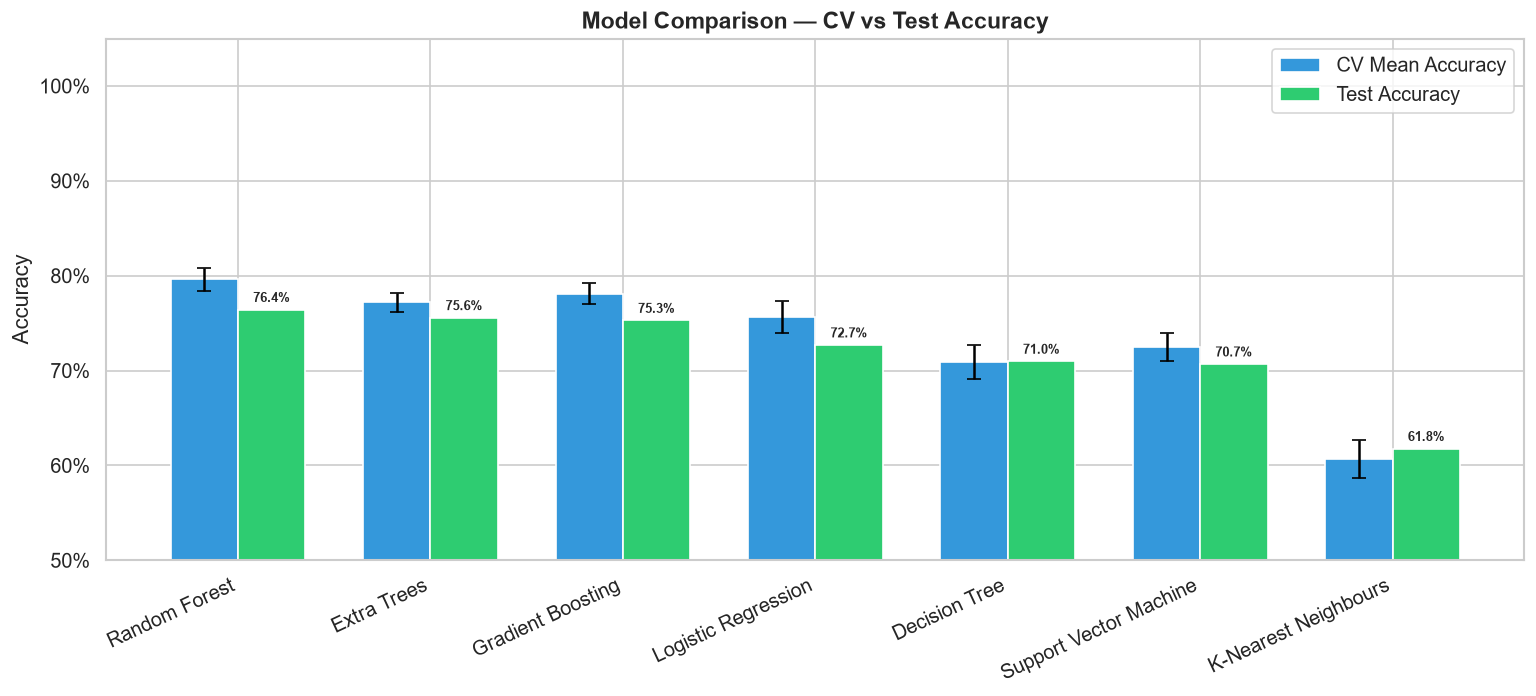

In [16]:
# ─── 15. COMPARISON CHART ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(results_df))
w = 0.35

bars1 = ax.bar(x - w/2, results_df['CV Mean Acc'],  w, label='CV Mean Accuracy',  color='#3498DB', edgecolor='white')
bars2 = ax.bar(x + w/2, results_df['Test Accuracy'], w, label='Test Accuracy',    color='#2ECC71', edgecolor='white')

ax.errorbar(
    x - w/2, results_df['CV Mean Acc'],
    yerr=results_df['CV Std'],
    fmt='none', color='black', capsize=4, linewidth=1.5
)

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=25, ha='right')
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison — CV vs Test Accuracy', fontsize=14, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

---
## 6 · Hyperparameter Tuning (Best Model)

In [17]:
# ─── 16. TUNE THE BEST MODEL (RANDOM FOREST) ──────────────────────────────────
param_dist = {
    'n_estimators'      : [100, 200, 300, 500],
    'max_depth'         : [None, 10, 20, 30, 40],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2', 0.3, 0.5],
    'class_weight'      : [None, 'balanced'],
    'bootstrap'         : [True, False]
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)

random_search = RandomizedSearchCV(
    rf_base, param_distributions=param_dist,
    n_iter=50, scoring='accuracy',
    cv=cv, n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)

random_search.fit(X_train_top, y_train)

print("\nBest parameters found:")
for k, v in random_search.best_params_.items():
    print(f"  {k:<25} : {v}")
print(f"\nBest CV accuracy      : {random_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits



Best parameters found:
  n_estimators              : 100
  min_samples_split         : 5
  min_samples_leaf          : 2
  max_features              : 0.5
  max_depth                 : None
  class_weight              : None
  bootstrap                 : True

Best CV accuracy      : 0.7984


In [18]:
# ─── 17. EVALUATE TUNED MODEL ─────────────────────────────────────────────────
best_model   = random_search.best_estimator_
y_pred_tuned = best_model.predict(X_test_top)
y_prob_tuned = best_model.predict_proba(X_test_top)

tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_f1  = f1_score(y_test, y_pred_tuned, average='weighted')

print("=" * 55)
print(f"  Tuned Random Forest — Test Accuracy : {tuned_acc:.4f} ({tuned_acc*100:.2f}%)")
print(f"  Tuned Random Forest — Weighted F1   : {tuned_f1:.4f}")
print("=" * 55)
print()
target_names = [label_map.get(c, c) for c in le_target.classes_]
print(classification_report(y_test, y_pred_tuned, target_names=target_names))

  Tuned Random Forest — Test Accuracy : 0.7701 (77.01%)
  Tuned Random Forest — Weighted F1   : 0.7516

                            precision    recall  f1-score   support

       Alzheimer's Disease       0.88      0.90      0.89        68
        Cognitively Normal       0.79      0.82      0.81        84
                 Early MCI       0.68      0.81      0.74        62
                  Late MCI       0.77      0.78      0.78       113
Significant Memory Concern       0.00      0.00      0.00        21

                  accuracy                           0.77       348
                 macro avg       0.62      0.66      0.64       348
              weighted avg       0.74      0.77      0.75       348



---
## 7 · Confusion Matrix & Clinical Insights

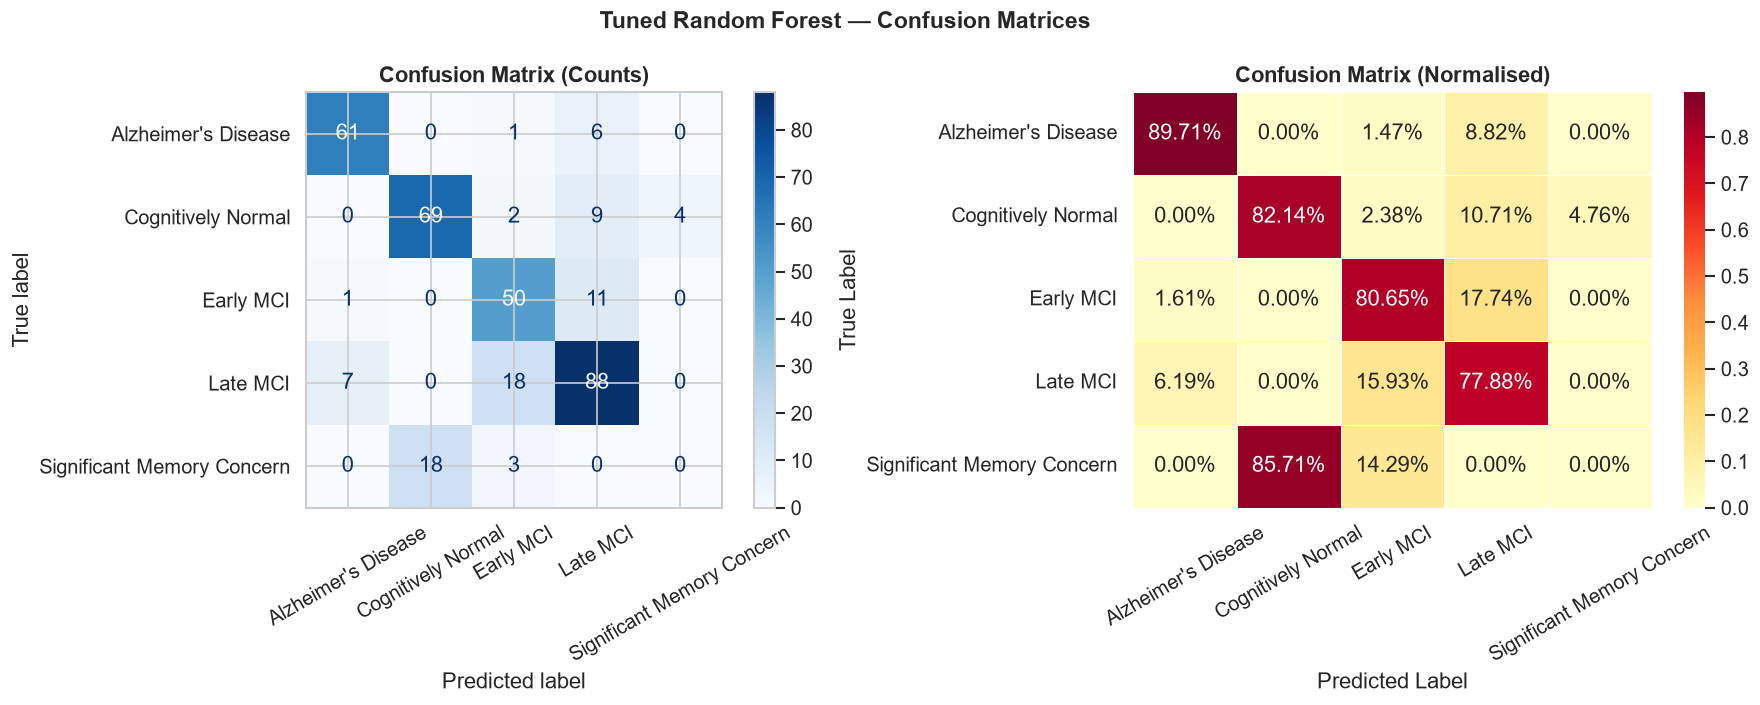

In [19]:
# ─── 18. CONFUSION MATRIX ─────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_tuned)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=axes[0], colorbar=True, cmap='Blues')
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# Normalised
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', ax=axes[1],
    xticklabels=target_names, yticklabels=target_names,
    cmap='YlOrRd', linewidths=0.5
)
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Tuned Random Forest — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

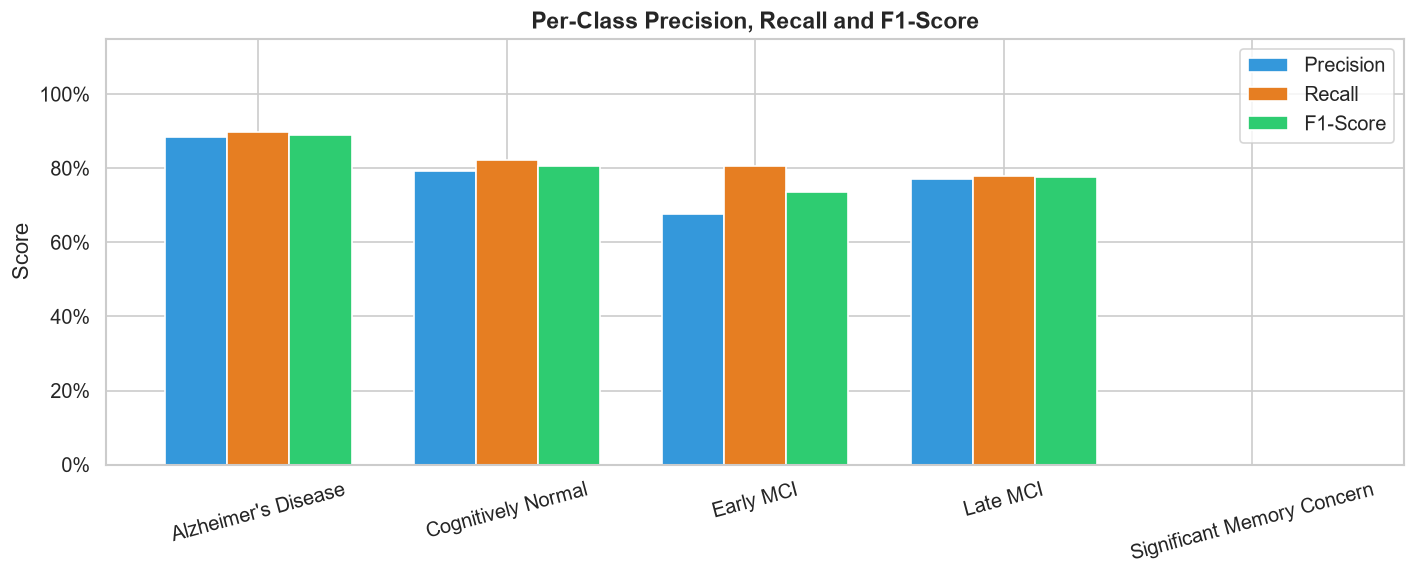

                 Diagnosis  Precision  Recall  F1-Score
       Alzheimer's Disease     0.8841  0.8971    0.8905
        Cognitively Normal     0.7931  0.8214    0.8070
                 Early MCI     0.6757  0.8065    0.7353
                  Late MCI     0.7719  0.7788    0.7753
Significant Memory Concern     0.0000  0.0000    0.0000


In [20]:
# ─── 19. PER-CLASS PERFORMANCE BREAKDOWN ──────────────────────────────────────
from sklearn.metrics import precision_score, recall_score

class_precision = precision_score(y_test, y_pred_tuned, average=None)
class_recall    = recall_score(y_test, y_pred_tuned, average=None)
class_f1        = f1_score(y_test, y_pred_tuned, average=None)

class_metrics = pd.DataFrame({
    'Diagnosis'  : target_names,
    'Precision'  : class_precision,
    'Recall'     : class_recall,
    'F1-Score'   : class_f1
})

x = np.arange(len(target_names))
w = 0.25
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w,   class_metrics['Precision'], w, label='Precision', color='#3498DB', edgecolor='white')
ax.bar(x,       class_metrics['Recall'],    w, label='Recall',    color='#E67E22', edgecolor='white')
ax.bar(x + w,   class_metrics['F1-Score'],  w, label='F1-Score',  color='#2ECC71', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(target_names, rotation=15)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision, Recall and F1-Score', fontsize=14, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig('per_class_metrics.png', bbox_inches='tight')
plt.show()
print(class_metrics.to_string(index=False))

---
## 8 · Feature Explainability

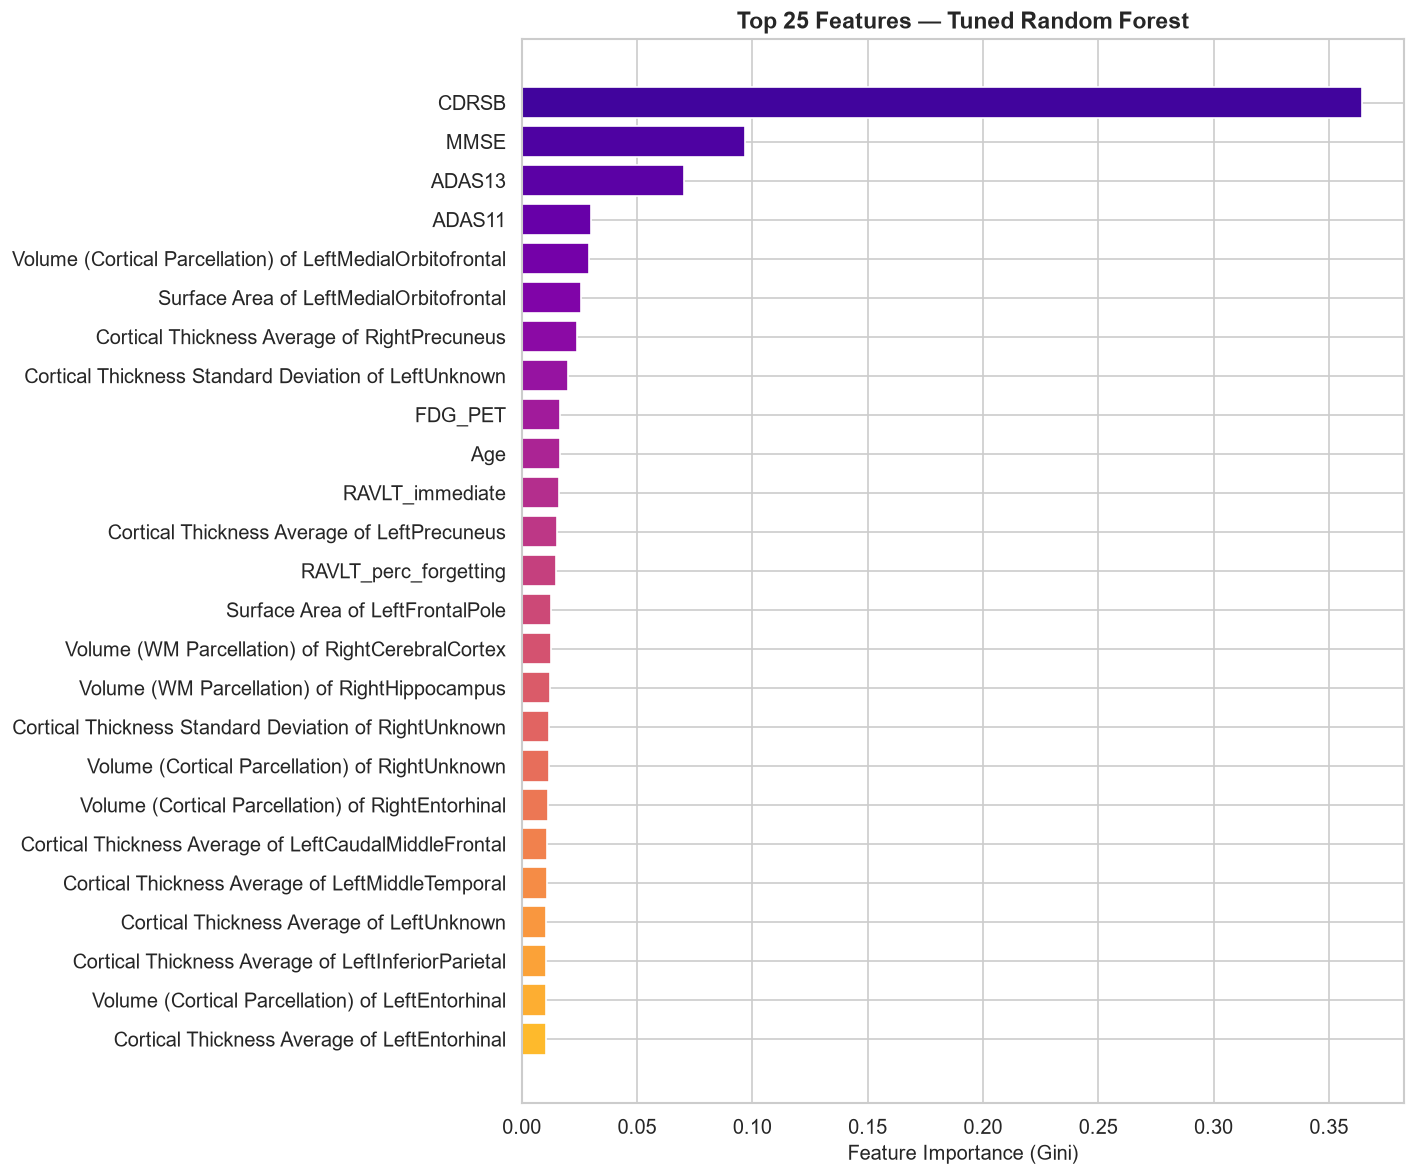

In [21]:
# ─── 20. FEATURE IMPORTANCE — TUNED MODEL ─────────────────────────────────────
tuned_importance = pd.DataFrame({
    'Feature'   : X_train_top.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 10))
top25 = tuned_importance.head(25)
colors_imp = plt.cm.plasma(np.linspace(0.1, 0.85, 25))
plt.barh(top25['Feature'][::-1], top25['Importance'][::-1], color=colors_imp[::-1])
plt.xlabel('Feature Importance (Gini)', fontsize=12)
plt.title('Top 25 Features — Tuned Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('tuned_feature_importance.png', bbox_inches='tight')
plt.show()

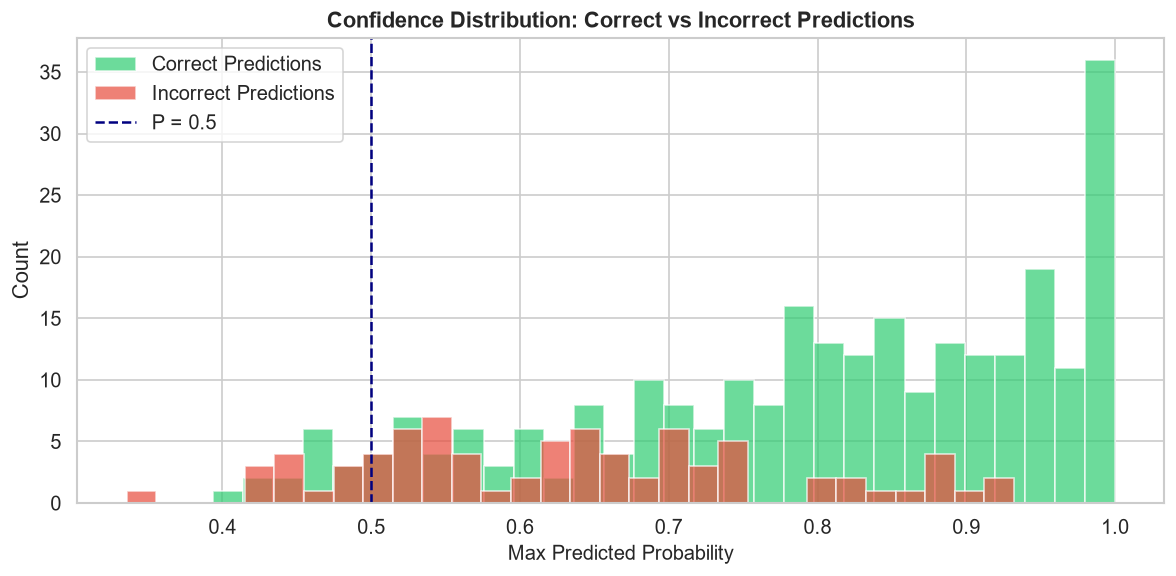

Mean confidence — correct   : 0.7996
Mean confidence — incorrect : 0.6326


In [22]:
# ─── 21. PREDICTION PROBABILITY DISTRIBUTION ──────────────────────────────────
correct_idx   = y_pred_tuned == y_test.values
max_probs     = y_prob_tuned.max(axis=1)

plt.figure(figsize=(10, 5))
plt.hist(max_probs[correct_idx],   bins=30, alpha=0.7, label='Correct Predictions',   color='#2ECC71', edgecolor='white')
plt.hist(max_probs[~correct_idx],  bins=30, alpha=0.7, label='Incorrect Predictions', color='#E74C3C', edgecolor='white')
plt.axvline(x=0.5, color='navy', linestyle='--', linewidth=1.5, label='P = 0.5')
plt.xlabel('Max Predicted Probability', fontsize=12)
plt.ylabel('Count')
plt.title('Confidence Distribution: Correct vs Incorrect Predictions', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('prediction_confidence.png', bbox_inches='tight')
plt.show()

print(f"Mean confidence — correct   : {max_probs[correct_idx].mean():.4f}")
print(f"Mean confidence — incorrect : {max_probs[~correct_idx].mean():.4f}")

---
## 9 · Final Summary

In [23]:
# ─── 22. FINAL SUMMARY ────────────────────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print("║          ALZHEIMER'S DIAGNOSIS — MODEL SUMMARY               ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  Dataset size           : {df.shape[0]:,} samples, {df.shape[1]} features        ║")
print(f"║  Features after cleaning: {X_train_top.shape[1]}                                 ║")
print(f"║  Train / Test split     : 80% / 20% (stratified)             ║")
print(f"║  Cross-validation       : Stratified 5-Fold                  ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  Best model             : Tuned Random Forest                ║")
print(f"║  Best CV Accuracy       : {random_search.best_score_*100:.2f}%                             ║")
print(f"║  Test Accuracy          : {tuned_acc*100:.2f}%                             ║")
print(f"║  Test Weighted F1       : {tuned_f1:.4f}                             ║")
print("╠══════════════════════════════════════════════════════════════╣")
print("║  Top 5 Predictive Features:                                  ║")
for i, row in tuned_importance.head(5).iterrows():          
    feat_short = row['Feature'][:42]
    print(f"║    {i}. {feat_short:<44}          ║")  
    
print("╚══════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════╗
║          ALZHEIMER'S DIAGNOSIS — MODEL SUMMARY               ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset size           : 1,737 samples, 371 features        ║
║  Features after cleaning: 40                                 ║
║  Train / Test split     : 80% / 20% (stratified)             ║
║  Cross-validation       : Stratified 5-Fold                  ║
╠══════════════════════════════════════════════════════════════╣
║  Best model             : Tuned Random Forest                ║
║  Best CV Accuracy       : 79.84%                             ║
║  Test Accuracy          : 77.01%                             ║
║  Test Weighted F1       : 0.7516                             ║
╠══════════════════════════════════════════════════════════════╣
║  Top 5 Predictive Features:                                  ║
║    0. CDRSB                                                 ║
║    2. MMSE              

---
## 10 · 방식 A — 결혼상태 × (나이·성별·유전위험) 교호작용 검정 ⭐

**질문:** *"결혼해체(사별·이혼)의 AD 위험 효과가 나이·성별·ApoE4에 따라 달라지는가?"*

$$\text{logit } P(\text{AD}) = \beta_0 + \beta_1\,\text{결혼해체} + \beta_2\,\text{Age} + \beta_3\,(\text{결혼해체}\times\text{Age}) + \text{성별} + \text{교육} + \text{ApoE4} + \cdots$$

- **β3(교호항)** 이 유의하면 → *"사별·이혼이 고령일수록 AD 위험을 더 키운다"* 같은 **결합효과** 입증.
- 성별 교호(결혼해체 × 성별), 유전 교호(결혼해체 × ApoE4)도 동일한 틀에서 함께 검정.
- **장점:** '독거' 프록시 없이 나이+결혼상태 결합효과를 정면 검증 → **순환 문제 없음.**

> 사용 라이브러리: `statsmodels` (설치 필요 시 `pip install statsmodels`)

In [ ]:
# ─── A1. 교호작용(interaction) 분석 — 데이터 구성 ──────────────────────────────────
# "결혼상태의 효과가 나이/성별/유전위험에 따라 달라지는가?" 를 검정한다.
#   logit P(AD) = β0 + β1·결혼해체 + β2·Age + β3·(결혼해체 × Age) + 성별 + 교육 + ApoE4 ...
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

# 결과변수: AD vs 비-AD (이진)
ia = df[['Diagnosis', 'Marital_status', 'Age', 'Gender', 'Year_education', 'High_risk_ApoE4']].copy()
ia['AD'] = (ia['Diagnosis'] == 'AD').astype(int)

# 결혼해체: 사별(Widowed)·이혼(Divorced)=1  vs  기혼(Married)=0 [기준범주]
#   'Never married'/'Unknown' 은 '해체'도 '기혼 기준'도 아니므로 주분석에서 제외
ia = ia[ia['Marital_status'].isin(['Married', 'Widowed', 'Divorced'])].copy()
ia['Dissolved'] = ia['Marital_status'].isin(['Widowed', 'Divorced']).astype(int)

# 공변량
ia['Female'] = (ia['Gender'] == 'Female').astype(int)
ia['ApoE4']  = ia['High_risk_ApoE4'].astype(float)   # ApoE4 대립유전자 수 (0/1/2)
ia['Educ']   = ia['Year_education'].astype(float)
ia = ia.dropna(subset=['Age', 'Female', 'ApoE4', 'Educ'])

# 연속변수 중심화(centering): 교호모형에서 주효과를 '평균 지점'에서 해석 가능하게
ia['Age_c']   = ia['Age']   - ia['Age'].mean()
ia['Educ_c']  = ia['Educ']  - ia['Educ'].mean()
ia['ApoE4_c'] = ia['ApoE4'] - ia['ApoE4'].mean()

print(f"분석 표본 N = {len(ia)}   |   AD = {ia['AD'].sum()}   |   결혼해체 = {ia['Dissolved'].sum()}")
print("\n결혼상태별 AD 유병률(원자료, 보정 전):")
print((ia.groupby('Marital_status')['AD'].agg(['mean', 'size'])
         .rename(columns={'mean': 'AD비율', 'size': 'N'}).round(3)).to_string())

In [ ]:
# ─── A2. 로지스틱 회귀 — 주효과 모형 vs 교호작용 모형 ─────────────────────────────
# 주효과만: logit P(AD) = β0 + β1·결혼해체 + β2·Age + 성별 + 교육 + ApoE4
m_main = smf.logit('AD ~ Dissolved + Age_c + Female + Educ_c + ApoE4_c', data=ia).fit(disp=0)

# 교호작용: 결혼해체 × (나이 / 성별 / ApoE4) 추가
#   logit P(AD) = ... + β3·(결혼해체 × Age) + (결혼해체 × 성별) + (결혼해체 × ApoE4)
m_int = smf.logit(
    'AD ~ Dissolved + Age_c + Female + Educ_c + ApoE4_c'
    ' + Dissolved:Age_c + Dissolved:Female + Dissolved:ApoE4_c',
    data=ia).fit(disp=0)

def or_table(res):
    ci = res.conf_int()
    t = pd.DataFrame({
        'coef(β)'       : res.params,
        'p-value'       : res.pvalues,
        'OR'            : np.exp(res.params),
        'OR 95% CI low' : np.exp(ci[0]),
        'OR 95% CI high': np.exp(ci[1]),
    })
    return t.round(4)

print("=" * 72)
print("주효과 모형 (Main effects only)")
print("=" * 72)
print(or_table(m_main).to_string())
print(f"\n  Pseudo R² = {m_main.prsquared:.4f}   AIC = {m_main.aic:.1f}")

print("\n" + "=" * 72)
print("교호작용 모형 (Interaction)   ← 방식 A")
print("=" * 72)
print(or_table(m_int).to_string())
print(f"\n  Pseudo R² = {m_int.prsquared:.4f}   AIC = {m_int.aic:.1f}")

In [ ]:
# ─── A3. 교호항 검정 — β3 유의성 & 결합 우도비 검정(LR test) ───────────────────────
# 교호항 3개를 통째로 넣었을 때 모형이 유의하게 개선되는가? (우도비 검정)
lr_stat = 2 * (m_int.llf - m_main.llf)
lr_df   = int(m_int.df_model - m_main.df_model)
lr_p    = stats.chi2.sf(lr_stat, lr_df)

print("[결합 검정] 교호항 3개 동시 투입이 모형을 개선하는가? (Likelihood-Ratio test)")
print(f"  LR chi2 = {lr_stat:.3f},  df = {lr_df},  p = {lr_p:.4f}")
print(f"  → {'유의: 교호작용 존재' if lr_p < 0.05 else '경계/비유의 (개별 교호항은 아래에서 확인)'}\n")

focus  = ['Dissolved:Age_c', 'Dissolved:Female', 'Dissolved:ApoE4_c']
labels = {'Dissolved:Age_c'  : '결혼해체 × 나이  ',
          'Dissolved:Female' : '결혼해체 × 여성  ',
          'Dissolved:ApoE4_c': '결혼해체 × ApoE4'}
print("[개별 교호항 β3] — 결혼해체 효과가 각 요인에 따라 달라지는가?")
for term in focus:
    b, p, orr = m_int.params[term], m_int.pvalues[term], np.exp(m_int.params[term])
    sig = '★ 유의' if p < 0.05 else '  n.s.'
    print(f"  {labels[term]}  OR = {orr:.3f}   p = {p:.4f}   {sig}")

print("\n해석 가이드:")
print("  · 결혼해체 × 나이 OR>1 & 유의  → '고령일수록 사별·이혼이 AD 위험을 더 키운다' 지지")
print("  · 결혼해체 × 여성 유의         → 결혼해체 효과가 성별에 따라 다름")
print("  · 결혼해체 × ApoE4 유의        → 결혼해체 효과가 유전위험에 따라 다름")

In [ ]:
# ─── A4. 시각화 — 나이에 따른 예측 AD 확률 (결혼해체 × 나이 교호작용) ──────────────
# 한글 폰트 (Windows: Malgun Gothic)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

age_grid = np.linspace(ia['Age'].quantile(0.05), ia['Age'].quantile(0.95), 60)
age_mean = ia['Age'].mean()

def predict_curve(dissolved):
    grid = pd.DataFrame({
        'Dissolved': dissolved,
        'Age_c'   : age_grid - age_mean,
        'Female'  : 0,   # 남성 기준
        'Educ_c'  : 0,   # 평균 교육
        'ApoE4_c' : 0,   # 평균 ApoE4
    })
    sf = m_int.get_prediction(grid).summary_frame(alpha=0.05)
    return sf['predicted'].values, sf['ci_lower'].values, sf['ci_upper'].values

fig, ax = plt.subplots(figsize=(10, 6))
for dissolved, color, lab in [(0, '#3498DB', '기혼 (Married)'),
                              (1, '#E74C3C', '결혼해체 (사별·이혼)')]:
    mean, lo, hi = predict_curve(dissolved)
    ax.plot(age_grid, mean, color=color, linewidth=2.5, label=lab)
    ax.fill_between(age_grid, lo, hi, color=color, alpha=0.15)

ax.set_xlabel('나이 (Age)', fontsize=12)
ax.set_ylabel('예측 AD 확률  P(AD)', fontsize=12)
ax.set_title('결혼해체 × 나이 교호작용: 나이에 따른 AD 위험\n(남성 · 평균 교육 · 평균 ApoE4 기준, 95% CI)',
             fontsize=13, fontweight='bold')
ax.legend(title='결혼상태', fontsize=11)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('interaction_marital_age.png', bbox_inches='tight')
plt.show()

print("두 곡선의 '벌어짐(기울기 차이)'이 곧 결혼해체 × 나이 교호작용(β3)의 시각적 표현입니다.")

### A5 · 해석 & 주의사항

**핵심 결과 — 방식 A(교호작용)**
- **결혼해체 × 나이** 교호항(β3)이 유의(OR > 1, p < 0.05)하면 → *"사별·이혼이 고령일수록 AD 위험을 더 키운다"* 는 **결합효과**가 통계적으로 입증됨. '독거' 프록시 없이 나이+결혼상태 결합효과를 정면 검증하므로 **순환 문제 없음**.
- 결혼해체 × 성별, 결혼해체 × ApoE4 교호항은 같은 틀에서 함께 검정 — 유의하면 각각 성별·유전위험에 따른 조절효과.

**해석 주의**
- 이 데이터는 **횡단(cross-sectional) 진단** 자료 → 인과가 아닌 **연관**으로 읽어야 함.
- 결혼해체의 *주효과* OR은 기준(기혼) 대비 평균 나이 지점에서의 값이며, 교호가 있으면 나이에 따라 방향/크기가 달라짐 → 반드시 **A4의 예측확률 곡선**과 함께 해석.
- 연속변수(Age·Educ·ApoE4)는 중심화(centering)했으므로 주효과 = *평균값 지점*에서의 효과.
- 민감도 분석: ① AD 대신 (LMCI+AD) 를 결과로, ② ApoE4를 보인자 여부(≥1)로, ③ 'Never married' 포함 3범주 결혼상태로 바꿔 재확인 권장.